In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import zipfile
tf.__version__

2025-05-14 18:21:37.991239: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747246898.211127      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747246898.277654      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


'2.18.0'

**Path do dataset e criação do gerador de imagens**


In [2]:
path_dataset = r'/kaggle/input/augmented-alzheimer-mri-dataset/AugmentedAlzheimerDataset'
image_data_get =tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function = tf.keras.applications.resnet50.preprocess_input,
    validation_split = 0.2
)


**Carregamento das imagens a partir do path e divisão entre treino e validação**

In [3]:
image_gen_train = image_data_get.flow_from_directory(
    path_dataset,
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'categorical',
    shuffle = True,
    subset = 'training'
)
image_gen_val = image_data_get.flow_from_directory(
    path_dataset,
    target_size = (224,224),
    batch_size = 32,
    class_mode = 'categorical',
    shuffle = True,
    subset = 'validation'
)

Found 27188 images belonging to 4 classes.
Found 6796 images belonging to 4 classes.


**Verificando índices**

In [4]:
image_gen_train.class_indices

{'MildDemented': 0,
 'ModerateDemented': 1,
 'NonDemented': 2,
 'VeryMildDemented': 3}

**Carregando modelo de transferência a partir de arquivo local**

In [5]:
modelo_transfer = r'/kaggle/input/transfer-leraning/keras/default/1/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5'
transfer_model = tf.keras.applications.ResNet50(
    weights=modelo_transfer,
    include_top=False,
    input_shape=(224,224,3)
)
display("Done")

I0000 00:00:1747246923.521464      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1747246923.522206      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


'Done'

**Testando qualidade da imagem**

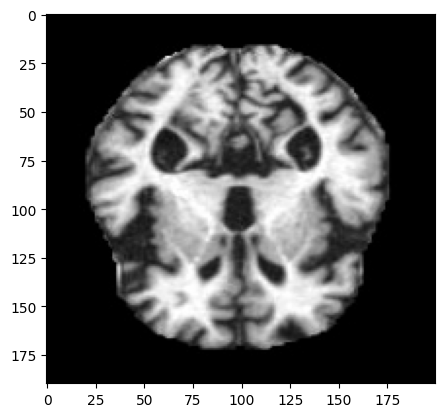

In [6]:
testing_image = r'/kaggle/input/augmented-alzheimer-mri-dataset/AugmentedAlzheimerDataset/ModerateDemented/001ef5a6-893b-4ede-9cf8-60b7fb94a541.jpg'

plt.imshow(plt.imread(testing_image))

**Verificando camadas entre convolucionais e densas**

In [7]:
for i, layers in enumerate(transfer_model.layers):
  print(i, layers)

0 <InputLayer name=input_layer, built=True>
1 <ZeroPadding2D name=conv1_pad, built=True>
2 <Conv2D name=conv1_conv, built=True>
3 <BatchNormalization name=conv1_bn, built=True>
4 <Activation name=conv1_relu, built=True>
5 <ZeroPadding2D name=pool1_pad, built=True>
6 <MaxPooling2D name=pool1_pool, built=True>
7 <Conv2D name=conv2_block1_1_conv, built=True>
8 <BatchNormalization name=conv2_block1_1_bn, built=True>
9 <Activation name=conv2_block1_1_relu, built=True>
10 <Conv2D name=conv2_block1_2_conv, built=True>
11 <BatchNormalization name=conv2_block1_2_bn, built=True>
12 <Activation name=conv2_block1_2_relu, built=True>
13 <Conv2D name=conv2_block1_0_conv, built=True>
14 <Conv2D name=conv2_block1_3_conv, built=True>
15 <BatchNormalization name=conv2_block1_0_bn, built=True>
16 <BatchNormalization name=conv2_block1_3_bn, built=True>
17 <Add name=conv2_block1_add, built=True>
18 <Activation name=conv2_block1_out, built=True>
19 <Conv2D name=conv2_block2_1_conv, built=True>
20 <BatchNorm

**Salvando camadas de output**

In [8]:
x = transfer_model.output

**Adicionando camadas densas de outputs**

In [9]:
x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(1024, activation='relu')(x)
x = tf.keras.layers.Dense(1024, activation='relu')(x)
x = tf.keras.layers.Dense(1024, activation='relu')(x)
x = tf.keras.layers.Dense(512, activation='relu')(x)
preds = tf.keras.layers.Dense(4, activation='softmax')(x)

**Mesclando modelo de transferência com novo output**

In [10]:
model = tf.keras.models.Model(inputs=transfer_model.input, outputs=preds)

**Verificando sumário da rede**

In [11]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 28,311,940 (108.00 MB)

 Trainable params: 28,258,820 (107.80 MB)

 Non-trainable params: 53,120 (207.50 KB)

**Verificando imagem pós-processamento**

(-0.5, 223.5, 223.5, -0.5)

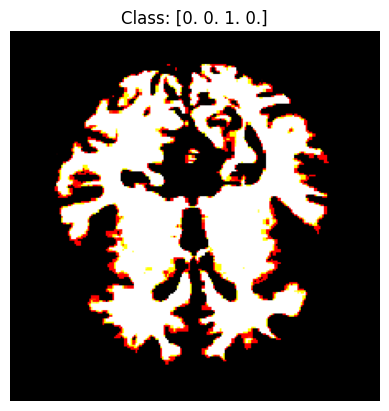

In [12]:
imagem, label = image_gen_train[1][0][0], image_gen_train[1][1][0]
plt.imshow(imagem)
plt.title(f"Class: {label}")
plt.axis('off')


In [13]:
image_gen_train[1][0][0]

array([[[-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        ...,
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ]],

       [[-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        ...,
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ]],

       [[-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        ...,
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ]],

       ...,

       [[-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        ...,
        [-103.939, -116.779, -123.68 ],
        [-103.939, -116.779, -123.68 ],
        [

**Compilando e treinando modelo**

In [ ]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(0.0001, decay=1e-6), loss='categorical_crossentropy',metrics=['accuracy'])
hist = model.fit(image_gen_train, validation_data=image_gen_train, epochs = 10, batch_size=512)

/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


**Verificando acurácia e sua validação durante o treino**

In [ ]:
acc = hist.history['accuracy']
val_acc = hist.history['val_accuracy']

In [ ]:
plt.plot(acc, label='Accuracy')
plt.plot(val_acc, label="Accuracy Validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy/Validation")
plt.figure()

**Verificando perda e sua validação durante o treino**

In [ ]:
loss = hist.history['loss']
val_loss = hist.history['val_loss']

In [ ]:
plt.plot(loss, label='Loss')
plt.plot(val_loss, label="Loss Validation")
plt.xlabel("Epochs")
plt.ylabel("Loss/Validation")
plt.figure()

**Path de testes**

In [ ]:
path_testing_dataset = r'/kaggle/input/augmented-alzheimer-mri-dataset/OriginalDataset'

**Criando gerador de imagens teste e processando-as**

In [ ]:
testing_image_data_gen = tf.keras.preprocessing.image.ImageDataGenerator(  
   preprocessing_function = tf.keras.applications.resnet50.preprocess_input
)

images = testing_image_data_gen.flow_from_directory(
    path_testing_dataset,
    target_size = (224,224),
    shuffle = False
)

**Verificando imagens da base de teste**

In [ ]:
l = 10
w = 10

fig, axes = plt.subplots(l, w, figsize = (15,15))
axes = axes.ravel()

for i in np.arange(0, l*w):
    random_index = random.randint(0, len(pred_classes) - 1)
    img_path = images.filepaths[random_index]
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img = tf.keras.utils.img_to_array(img) / 255.0  # Para exibir corretamente

    axes[i].imshow(img)
    axes[i].set_title(f"True: {class_labels[true_classes[random_index]]}\n"
                      f"Pred: {class_labels[pred_classes[random_index]]}")
    axes[i].axis('off')
plt.subplots_adjust(hspace=1)

**Prevendo classes**

In [ ]:

pred = model.predict(images)
pred_classes = np.argmax(pred, axis=1)


**Verificando acurácia, matriz de confusão, e metricas de classificação do modelo com a base de teste**

In [ ]:
true_classes = images.classes
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
accuracy_score(true_classes, pred_classes)

In [ ]:
cm = confusion_matrix(true_classes, pred_classes)
sns.heatmap(cm, annot=True)

In [ ]:
cr = classification_report(true_classes, pred_classes, target_names=images.class_indices.keys())
print(cr)

**Visualizando comparação entre classe real e previsão do modelo**

In [ ]:
l = 10
w = 10

fig, axes = plt.subplots(l, w, figsize = (15,15))
axes = axes.ravel()

true_classes = images.classes
class_labels = list(images.class_indices.keys())

for i in np.arange(0, l*w):
    random_index = random.randint(0, len(pred_classes)-1)
    img_path = images.filepaths[random_index]
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img = tf.keras.utils.img_to_array(img) / 255.0  

    axes[i].imshow(img)
    axes[i].set_title(f"True: {true_classes[random_index]}\n"
                      f"Pred: {pred_classes[random_index]}")
    axes[i].axis('off')
plt.subplots_adjust(hspace=.7)